In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(
  style='darkgrid',
)

In [21]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


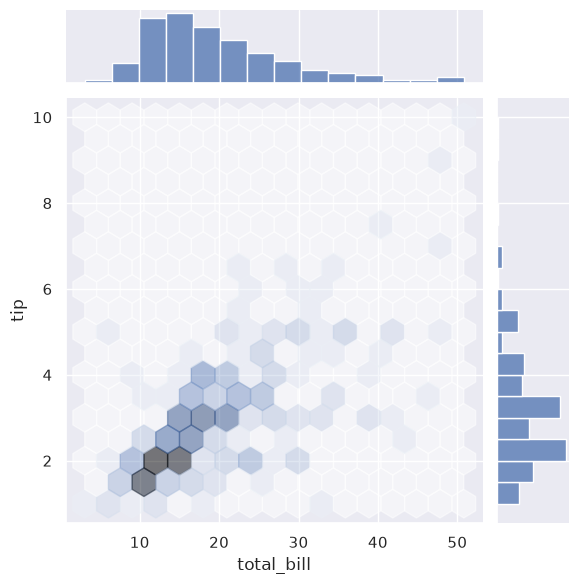

In [79]:
sns.jointplot(data=df, x='total_bill', y='tip', alpha=0.5, kind='hex')
#INFO: Total bill ~ Tip

<Axes: xlabel='total_bill', ylabel='tip'>

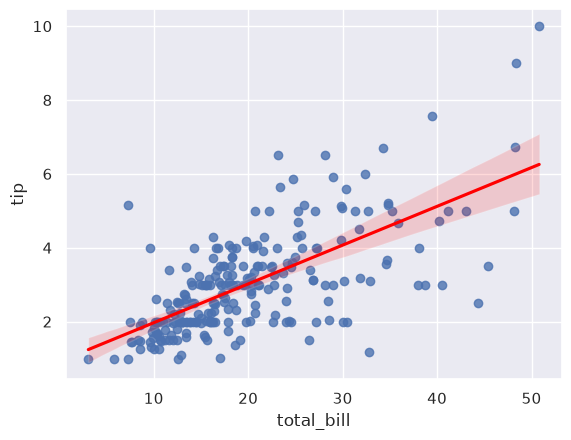

In [81]:
sns.regplot(data=df, x='total_bill', y='tip', line_kws={'color': 'red'})

<Axes: xlabel='tip', ylabel='Density'>

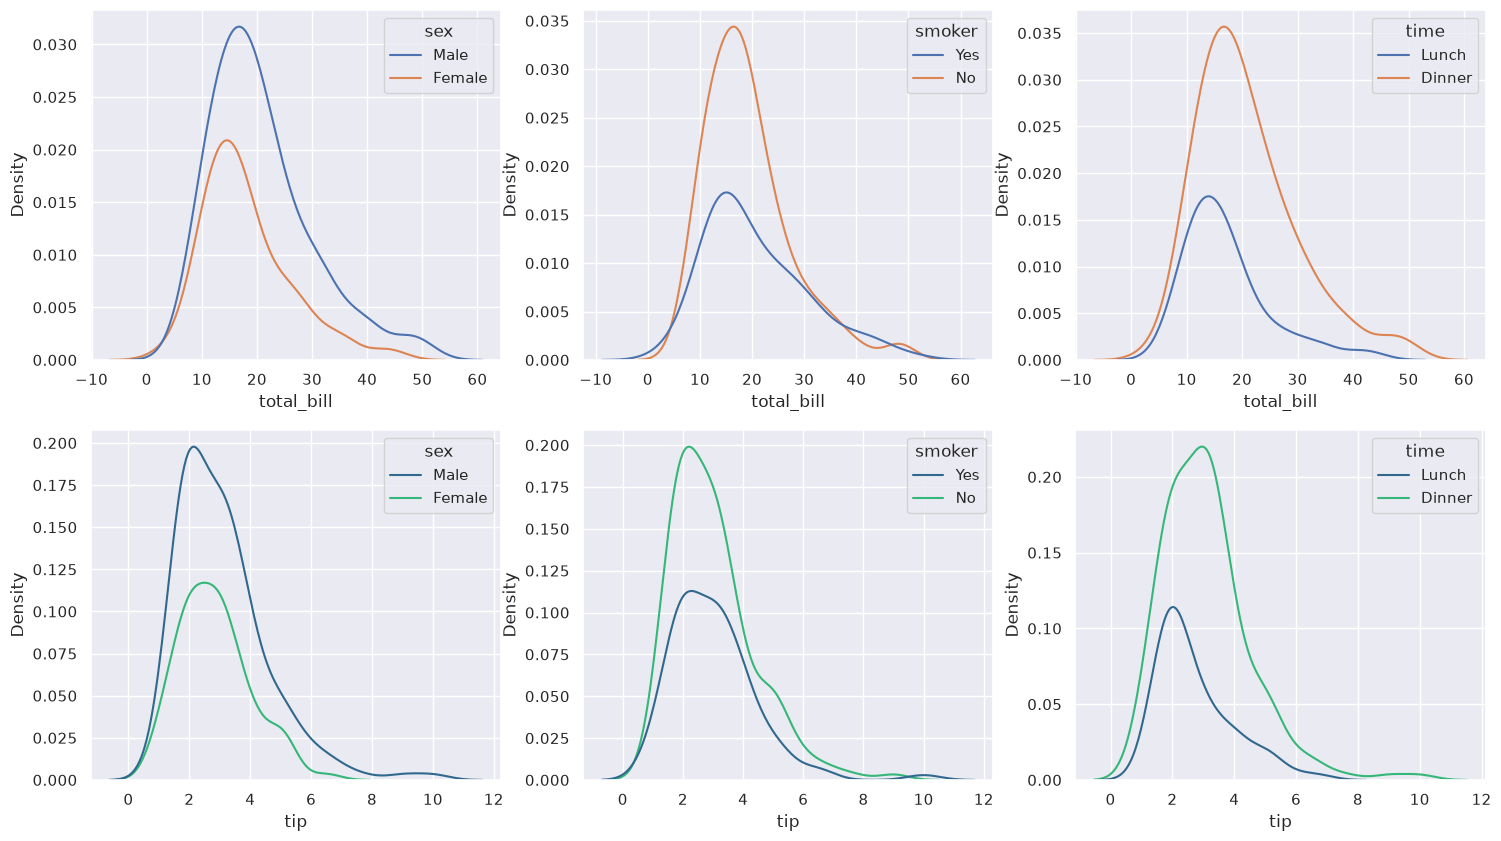

In [52]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(18, 10))

sns.kdeplot(data=df, x='total_bill', hue='sex', ax=ax1)
sns.kdeplot(data=df, x='total_bill', hue='smoker', ax=ax2)
sns.kdeplot(data=df, x='total_bill', hue='time', ax=ax3)

#INFO: Male-total_bill > Female-total_bill
#INFO: Non_smoker-total_bill > Smoker-total_bill
#INFO: Dinner-total_bill > Lunch-total_bill


sns.kdeplot(data=df, x='tip', hue='sex', ax=ax4, palette='viridis')
sns.kdeplot(data=df, x='tip', hue='smoker', ax=ax5, palette='viridis')
sns.kdeplot(data=df, x='tip', hue='time', ax=ax6, palette='viridis')

<Axes: xlabel='time', ylabel='tip'>

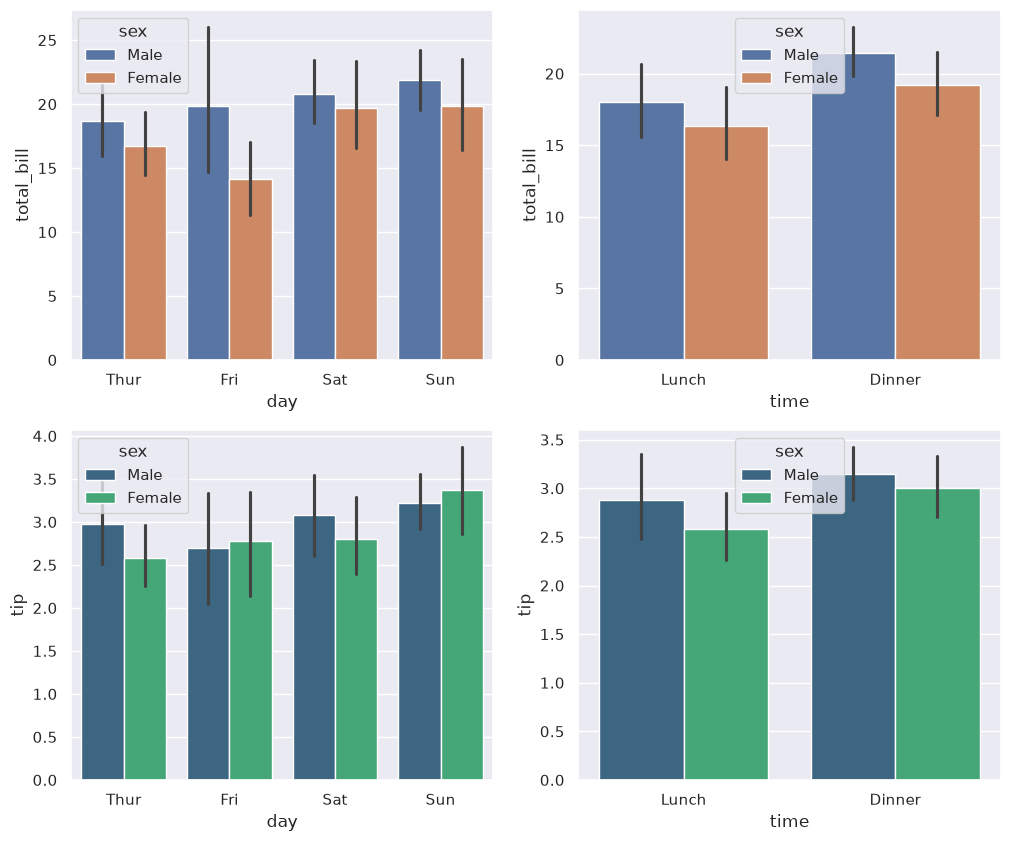

In [54]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(data=df, x='day', y='total_bill', hue='sex', ax=ax1)
sns.barplot(data=df, x='time', y='total_bill', hue='sex', ax=ax2)

sns.barplot(data=df, x='day', y='tip', hue='sex', ax=ax3, palette='viridis')
sns.barplot(data=df, x='time', y='tip', hue='sex', ax=ax4, palette='viridis')

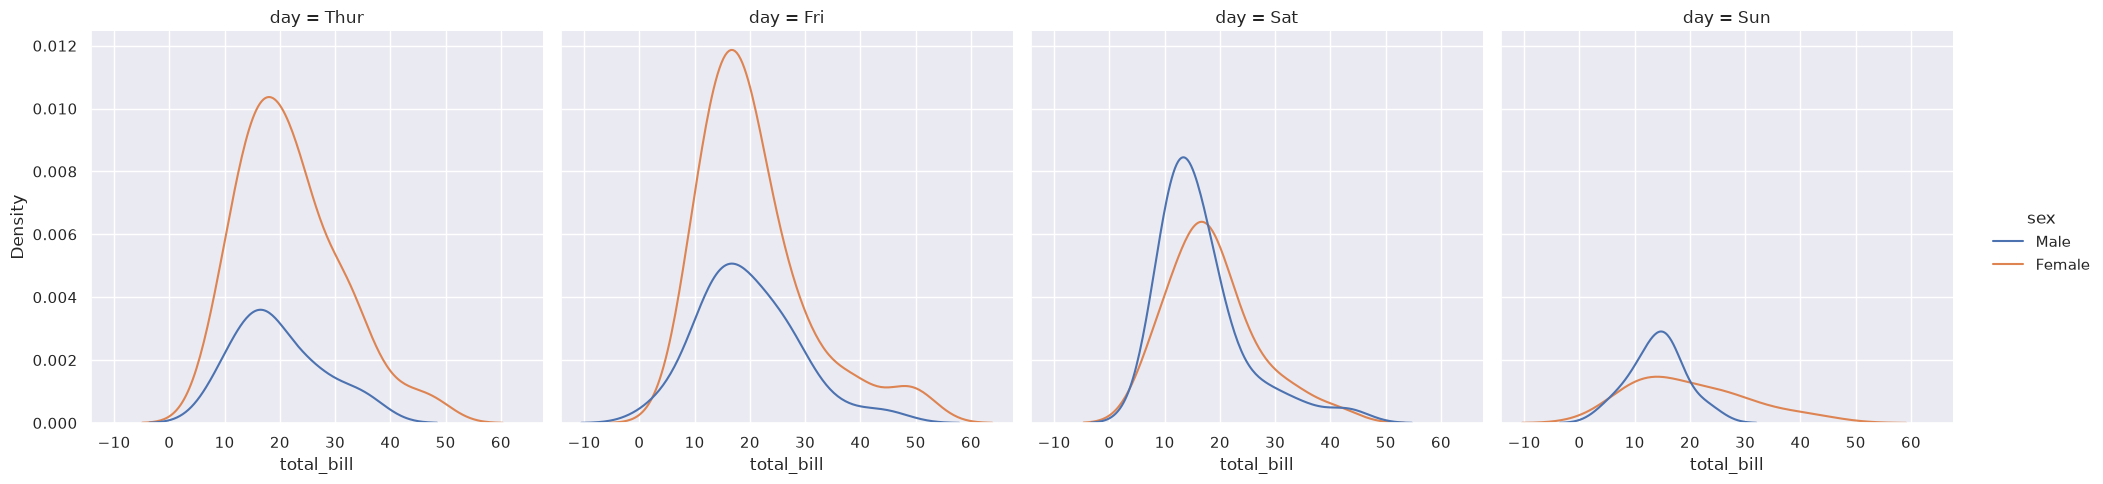

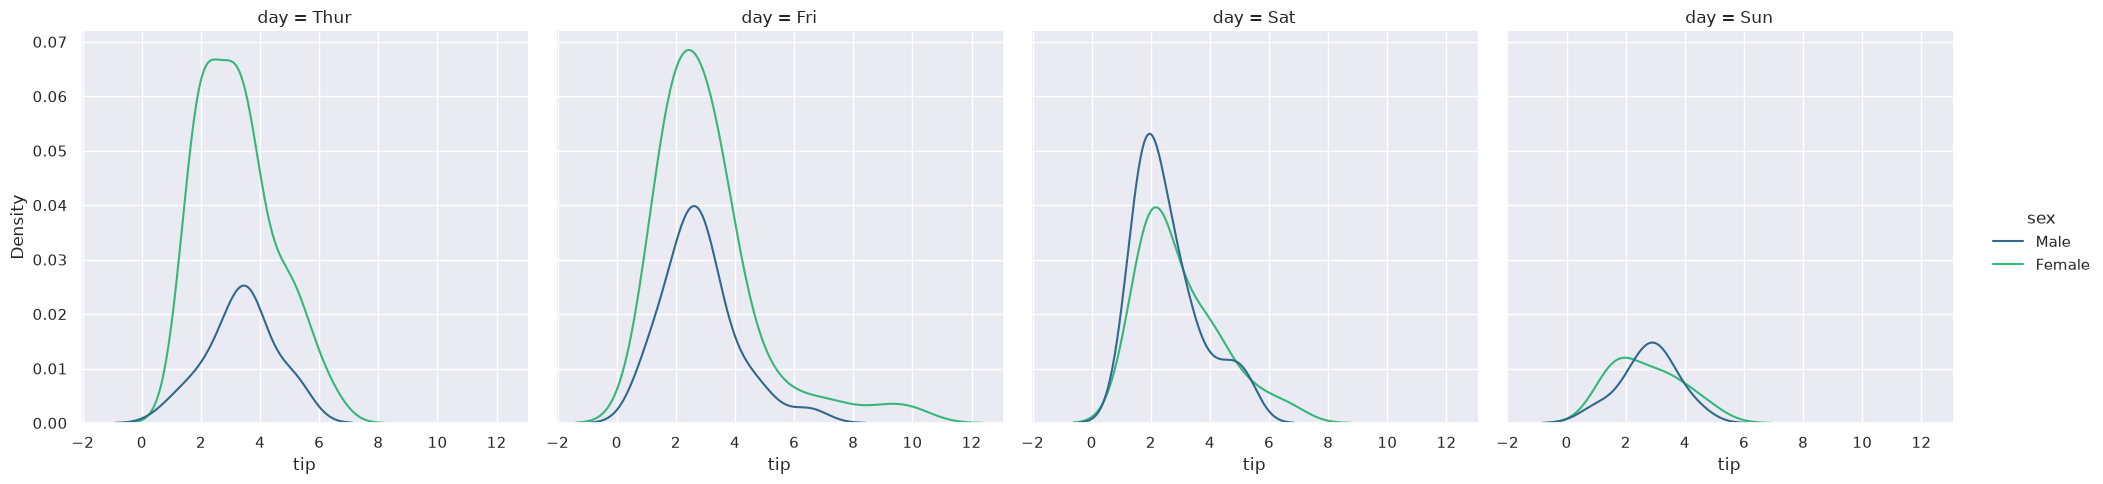

In [56]:
sns.displot(data=df, x='total_bill', hue='sex', col='day', kind='kde')
sns.displot(data=df, x='tip', hue='sex', col='day', kind='kde', palette='viridis')

<Axes: >

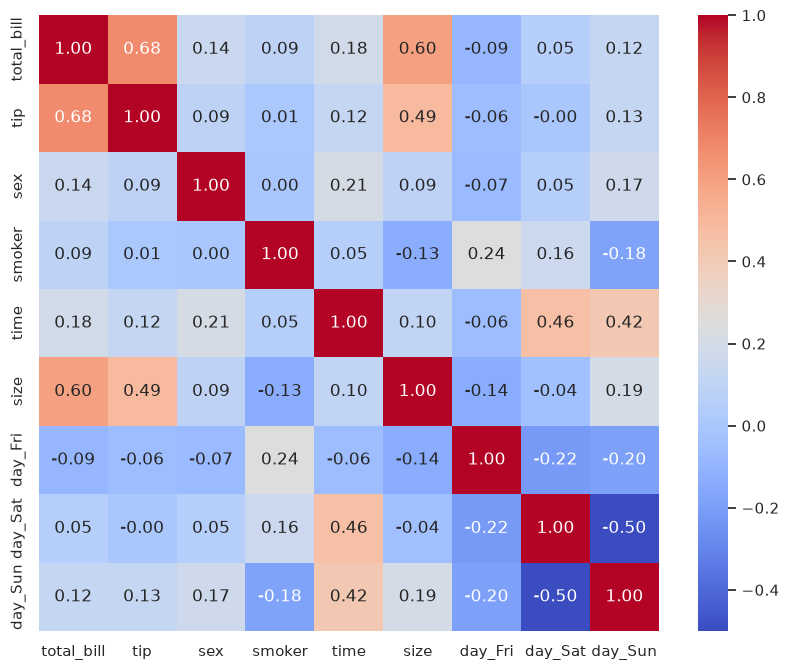

In [67]:
df_modified = df.copy()
df_modified['sex'] = df_modified['sex'].map({'Male': 1, 'Female': 0})
df_modified['smoker'] = df_modified['smoker'].map({'Yes': 1, 'No': 0})
df_modified['time'] = df_modified['time'].map({'Dinner': 1, 'Lunch': 0})
df_modified = pd.get_dummies(df_modified, columns=['day'], drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_modified.corr(), cmap='coolwarm', annot=True, fmt='.2f', )